In [5]:
# del model, model2, model3, model4

In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision import models

In [7]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import shutil
import os

SRC_PATH = "/content/drive/MyDrive/Smart_Vision"
DEST_PATH = "/content/Smart_Vision"

# Remove existing copy (important to avoid errors)
if os.path.exists(DEST_PATH):
    shutil.rmtree(DEST_PATH)

# Copy dataset
shutil.copytree(SRC_PATH, DEST_PATH)

print("Dataset copied to runtime successfully!")

Dataset copied to runtime successfully!


In [9]:
# Define Paths
BASE_PATH = "/content/Smart_Vision"

TRAIN_PATH = f"{BASE_PATH}/classification/train"
VAL_PATH   = f"{BASE_PATH}/classification/val"
TEST_PATH  = f"{BASE_PATH}/classification/test"

In [10]:
# print("GPU Available:", torch.cuda.is_available())
# print("GPU Name:", torch.cuda.get_device_name(0))

In [11]:
# setting device to cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [12]:
# Hyper Parameters
BATCH_SIZE = 32
LR = 0.0001
EPOCHS = 15
NUM_CLASSES = 26

In [13]:
# Define Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [14]:
train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_PATH, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)
print("Number of Classes:", len(class_names))

Classes: ['airplane', 'bed', 'bench', 'bicycle', 'bird', 'bottle', 'bowl', 'bus', 'cake', 'car', 'cat', 'chair', 'couch', 'cow', 'cup', 'dog', 'elephant', 'horse', 'motorcycle', 'person', 'pizza', 'potted plant', 'stop sign', 'traffic light', 'train', 'truck']
Number of Classes: 26


In [15]:
# Create training function

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):

    model.to(device)
    best_val_acc = float('-inf')
    patience = 5
    counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()

        train_acc = train_correct / len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss, val_correct = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        print("-"*40)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "vgg16_best.pth")
            counter = 0
        # else:
        #     counter += 1
        #     if counter >= patience:
        #         print("Early stopping triggered")
        #         break

In [16]:
# Create Evaluation Function
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

    acc = correct / len(test_loader.dataset)
    print("Test Accuracy:", acc)


In [17]:
# Define Test Loaders
test_dataset = datasets.ImageFolder(TEST_PATH, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Augmentation and Model Training

In [18]:
# Augmentation Part
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# val/test transforms without augmentation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [19]:
# Updated Data Loaders
train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_PATH, transform=val_transform)
test_dataset  = datasets.ImageFolder(TEST_PATH, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Model 1: VGG16

In [20]:
# del model

In [21]:
# Load pre-trained model
from torchvision import models

model = models.vgg16(pretrained=True)

# freeze convolutional layers
for param in model.parameters():
    param.requires_grad = False

# Modify the classifier
model.classifier = nn.Sequential(
    nn.Linear(25088, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, NUM_CLASSES)
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 159MB/s]


In [22]:
# Define Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [23]:
train_model(model, train_loader, val_loader, criterion, optimizer, EPOCHS)

Epoch 1/15
Train Loss: 130.5613, Train Acc: 0.3738
Val Loss: 24.0137, Val Acc: 0.4639
----------------------------------------
Epoch 2/15
Train Loss: 69.1633, Train Acc: 0.6729
Val Loss: 21.0656, Val Acc: 0.5309
----------------------------------------
Epoch 3/15
Train Loss: 47.3497, Train Acc: 0.7911
Val Loss: 19.7590, Val Acc: 0.5284
----------------------------------------
Epoch 4/15
Train Loss: 36.1426, Train Acc: 0.8384
Val Loss: 21.2781, Val Acc: 0.4923
----------------------------------------
Epoch 5/15
Train Loss: 28.5247, Train Acc: 0.8747
Val Loss: 19.9085, Val Acc: 0.5232
----------------------------------------
Epoch 6/15
Train Loss: 22.0792, Train Acc: 0.9076
Val Loss: 21.1127, Val Acc: 0.5129
----------------------------------------
Epoch 7/15
Train Loss: 18.9392, Train Acc: 0.9186
Val Loss: 20.9188, Val Acc: 0.5155
----------------------------------------
Epoch 8/15
Train Loss: 15.1564, Train Acc: 0.9357
Val Loss: 20.7644, Val Acc: 0.5026
--------------------------------

In [24]:
model.load_state_dict(torch.load("vgg16_best.pth"))

<All keys matched successfully>

In [25]:
evaluate_model(model, test_loader)

Test Accuracy: 0.5282051282051282


In [26]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/Smart_Vision/vgg16_best.pth"
)

# Model 2: ResNet50

In [27]:
# del model2

In [28]:
from torchvision import models

In [29]:
model2 = models.resnet50(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 175MB/s]


In [30]:
# define loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model2.parameters()),
    lr=0.0001,
    weight_decay=1e-4
)

In [31]:
# training loop

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.3)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):

    model.to(device)
    best_val_acc = float('-inf')
    patience = 5
    counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()

        train_acc = train_correct / len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss, val_correct = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        print("-"*40)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "resnet_best.pth")
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered")
                break
        scheduler.step()

In [32]:
# freeze layers
for param in model2.parameters():
    param.requires_grad = False

# unfreeze n last layers
for param in model2.layer4.parameters():  # last block
    param.requires_grad = True

# replace final layer
model2.fc = nn.Sequential(
    nn.Linear(model2.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.6),
    nn.Linear(256, NUM_CLASSES)
)

In [33]:
train_model(model2, train_loader, val_loader, criterion, optimizer, EPOCHS)

Epoch 1/15
Train Loss: 170.0597, Train Acc: 0.2529
Val Loss: 35.4963, Val Acc: 0.3995
----------------------------------------
Epoch 2/15
Train Loss: 135.0482, Train Acc: 0.5195
Val Loss: 30.8179, Val Acc: 0.4768
----------------------------------------
Epoch 3/15
Train Loss: 110.0578, Train Acc: 0.6432
Val Loss: 27.4053, Val Acc: 0.5180
----------------------------------------
Epoch 4/15
Train Loss: 90.5559, Train Acc: 0.7262
Val Loss: 26.2705, Val Acc: 0.5052
----------------------------------------
Epoch 5/15
Train Loss: 75.5528, Train Acc: 0.8004
Val Loss: 24.9724, Val Acc: 0.5077
----------------------------------------
Epoch 6/15
Train Loss: 64.6480, Train Acc: 0.8538
Val Loss: 25.1068, Val Acc: 0.5412
----------------------------------------
Epoch 7/15
Train Loss: 59.3524, Train Acc: 0.8747
Val Loss: 24.3981, Val Acc: 0.5490
----------------------------------------
Epoch 8/15
Train Loss: 54.9081, Train Acc: 0.8999
Val Loss: 24.2957, Val Acc: 0.5464
------------------------------

In [34]:
model2.load_state_dict(torch.load("resnet_best.pth"))

<All keys matched successfully>

In [35]:
evaluate_model(model2, test_loader)

Test Accuracy: 0.5051282051282051


In [36]:
evaluate_model(model2, test_loader)


Test Accuracy: 0.5051282051282051


In [37]:
torch.save(
    model2.state_dict(),
    "/content/drive/MyDrive/Smart_Vision/resnet50_best.pth"
)

# Model 3: MobileNetV2

In [38]:
from torchvision import models

model3 = models.mobilenet_v2(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 130MB/s]


In [39]:
# freeze all layers
for param in model3.features.parameters():
    param.requires_grad = False

# unfreeze layers
for param in model3.features[-4:].parameters():
    param.requires_grad = True

# classifier setup
import torch.nn as nn

model3.classifier = nn.Sequential(
    nn.Linear(model3.last_channel, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, NUM_CLASSES)
)

In [40]:
# loss and optimizer
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model3.classifier.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

In [41]:
# training loop

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.3)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):

    model.to(device)
    best_val_acc = float('-inf')
    patience = 5
    counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()

        train_acc = train_correct / len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss, val_correct = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        print("-"*40)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "mobilenetv2_best.pth")
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered")
                break
        scheduler.step()

In [42]:
train_model(model3, train_loader, val_loader, criterion, optimizer, epochs=50)

Epoch 1/50
Train Loss: 181.4824, Train Acc: 0.0940
Val Loss: 40.2419, Val Acc: 0.2577
----------------------------------------
Epoch 2/50
Train Loss: 168.6384, Train Acc: 0.2358
Val Loss: 37.4560, Val Acc: 0.3582
----------------------------------------
Epoch 3/50
Train Loss: 154.2546, Train Acc: 0.3342
Val Loss: 34.4150, Val Acc: 0.3840
----------------------------------------
Epoch 4/50
Train Loss: 141.2072, Train Acc: 0.3870
Val Loss: 32.0520, Val Acc: 0.3866
----------------------------------------
Epoch 5/50
Train Loss: 129.0779, Train Acc: 0.4596
Val Loss: 30.2024, Val Acc: 0.4201
----------------------------------------
Epoch 6/50
Train Loss: 122.7058, Train Acc: 0.4711
Val Loss: 29.4773, Val Acc: 0.4072
----------------------------------------
Epoch 7/50
Train Loss: 119.6030, Train Acc: 0.4777
Val Loss: 29.0209, Val Acc: 0.4175
----------------------------------------
Epoch 8/50
Train Loss: 117.1862, Train Acc: 0.5003
Val Loss: 28.6994, Val Acc: 0.4149
-------------------------

In [43]:
model3.load_state_dict(torch.load("mobilenetv2_best.pth"))

<All keys matched successfully>

In [44]:
evaluate_model(model3, test_loader)

Test Accuracy: 0.3564102564102564


In [45]:
torch.save(
    model3.state_dict(),
    "/content/drive/MyDrive/Smart_Vision/mobilenetv2_best.pth"
)

# Model 4: EfficientNetB0

In [46]:
# del model4

In [47]:
model4 = models.efficientnet_b0(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 110MB/s] 


In [48]:
# freeze layers
for param in model4.features.parameters():
    param.requires_grad = False
# unfreeze
for param in model4.features[-4:].parameters():
    param.requires_grad = True

# classfier setup
model4.classifier = nn.Sequential(
    nn.Linear(model4.classifier[1].in_features, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, NUM_CLASSES)
)

In [49]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model4.classifier.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

In [50]:
# training loop

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.3)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):

    model.to(device)
    best_val_acc = float('-inf')
    patience = 5
    counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()

        train_acc = train_correct / len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss, val_correct = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        print("-"*40)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "efficientnetb0_best.pth")
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered")
                break
        scheduler.step()

In [51]:
train_model(model4, train_loader, val_loader, criterion, optimizer, epochs=50)

Epoch 1/50
Train Loss: 180.5387, Train Acc: 0.1111
Val Loss: 39.2266, Val Acc: 0.1830
----------------------------------------
Epoch 2/50
Train Loss: 152.8148, Train Acc: 0.3123
Val Loss: 35.6179, Val Acc: 0.3015
----------------------------------------
Epoch 3/50
Train Loss: 132.3932, Train Acc: 0.4717
Val Loss: 33.0102, Val Acc: 0.3918
----------------------------------------
Epoch 4/50
Train Loss: 118.4220, Train Acc: 0.5569
Val Loss: 31.3544, Val Acc: 0.4201
----------------------------------------
Epoch 5/50
Train Loss: 107.9426, Train Acc: 0.5970
Val Loss: 29.6907, Val Acc: 0.4356
----------------------------------------
Epoch 6/50
Train Loss: 101.8495, Train Acc: 0.6322
Val Loss: 29.4096, Val Acc: 0.4381
----------------------------------------
Epoch 7/50
Train Loss: 99.6878, Train Acc: 0.6405
Val Loss: 28.9286, Val Acc: 0.4407
----------------------------------------
Epoch 8/50
Train Loss: 95.9683, Train Acc: 0.6553
Val Loss: 28.9229, Val Acc: 0.4356
---------------------------

In [52]:
model4.load_state_dict(torch.load("efficientnetb0_best.pth"))

<All keys matched successfully>

In [53]:
evaluate_model(model4, test_loader)

Test Accuracy: 0.46923076923076923


In [54]:
torch.save(
    model4.state_dict(),
    "/content/drive/MyDrive/Smart_Vision/efficientnetb0_best.pth"
)

# Model Comparision and Selection

In [55]:
from sklearn.metrics import classification_report, confusion_matrix
import torch
import numpy as np
import time

def eval_model(model, test_loader, class_names, device):

    model.eval()

    all_preds = []
    all_labels = []

    correct = 0
    total = 0

    inference_times = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            start_time = time.time()

            outputs = model(images)

            end_time = time.time()

            inference_times.append(end_time - start_time)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total

    avg_inference_time = np.mean(inference_times)

    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        output_dict=True
    )

    cm = confusion_matrix(all_labels, all_preds)

    return accuracy, avg_inference_time, report, cm

In [56]:
vgg_acc, vgg_time, vgg_report, vgg_cm = eval_model(
    model,
    test_loader,
    class_names,
    device
)

In [57]:
mobilenet_acc, mobilenet_time, mobilenet_report, mobilenet_cm = eval_model(
    model3,
    test_loader,
    class_names,
    device
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [58]:
resnet_acc, resnet_time, resnet_report, resnet_cm = eval_model(
    model2,
    test_loader,
    class_names,
    device
)

In [59]:
efficientnet_acc, efficientnet_time, efficientnet_report, efficientnet_cm = eval_model(
    model4,
    test_loader,
    class_names,
    device
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [60]:
models_results = {
    "VGG16": {
        "Accuracy": vgg_acc,
        "Precision": vgg_report["weighted avg"]["precision"],
        "Recall": vgg_report["weighted avg"]["recall"],
        "F1": vgg_report["weighted avg"]["f1-score"],
        "Inference Time": vgg_time
    },
    "ResNet": {
        "Accuracy": resnet_acc,
        "Precision": resnet_report["weighted avg"]["precision"],
        "Recall": resnet_report["weighted avg"]["recall"],
        "F1": resnet_report["weighted avg"]["f1-score"],
        "Inference Time": resnet_time
    },
    "MobileNet": {
        "Accuracy": mobilenet_acc,
        "Precision": mobilenet_report["weighted avg"]["precision"],
        "Recall": mobilenet_report["weighted avg"]["recall"],
        "F1": mobilenet_report["weighted avg"]["f1-score"],
        "Inference Time": mobilenet_time
    },
    "EfficientNet": {
        "Accuracy": efficientnet_acc,
        "Precision": efficientnet_report["weighted avg"]["precision"],
        "Recall": efficientnet_report["weighted avg"]["recall"],
        "F1": efficientnet_report["weighted avg"]["f1-score"],
        "Inference Time": efficientnet_time
    }
}

In [61]:
import os

vgg_size = os.path.getsize("vgg16_best.pth") / (1024 * 1024)
print(f"VGG16 Size: {vgg_size:.2f} MB")

resnet_size = os.path.getsize("resnet_best.pth") / (1024 * 1024)
print(f"ResNet Size: {resnet_size:.2f} MB")

mobilenet_size = os.path.getsize("mobilenetv2_best.pth") / (1024 * 1024)
print(f"MobileNet Size: {mobilenet_size:.2f} MB")

efficientnet_size = os.path.getsize("efficientnetb0_best.pth") / (1024 * 1024)
print(f"EfficientNet Size: {efficientnet_size:.2f} MB")

VGG16 Size: 105.20 MB
ResNet Size: 92.01 MB
MobileNet Size: 10.00 MB
EfficientNet Size: 16.86 MB


In [62]:
def top5_accuracy(model, test_loader, device):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, top5 = outputs.topk(5, dim=1)

            for i in range(labels.size(0)):
                if labels[i] in top5[i]:
                    correct += 1

            total += labels.size(0)

    return correct / total

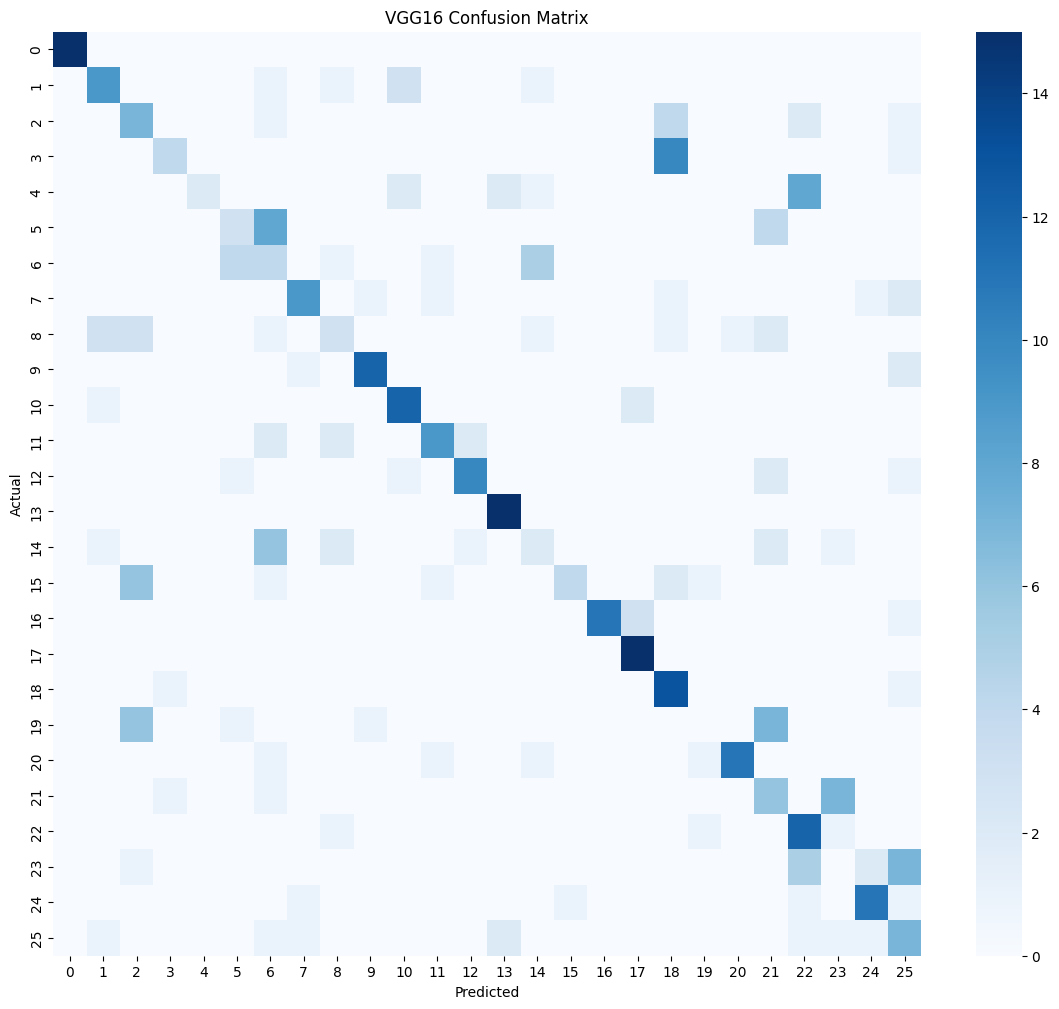

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,12))

sns.heatmap(
    vgg_cm,
    cmap="Blues"
)

plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [64]:
import pandas as pd

results_df = pd.DataFrame(models_results).T

results_df

,Accuracy,Precision,Recall,F1,Inference Time
VGG16,0.528205,0.563262,0.528205,0.512188,0.002314
ResNet,0.505128,0.509741,0.505128,0.481047,0.007844
MobileNet,0.356410,0.377326,0.356410,0.327234,0.010075
EfficientNet,0.469231,0.426508,0.469231,0.422379,0.010825


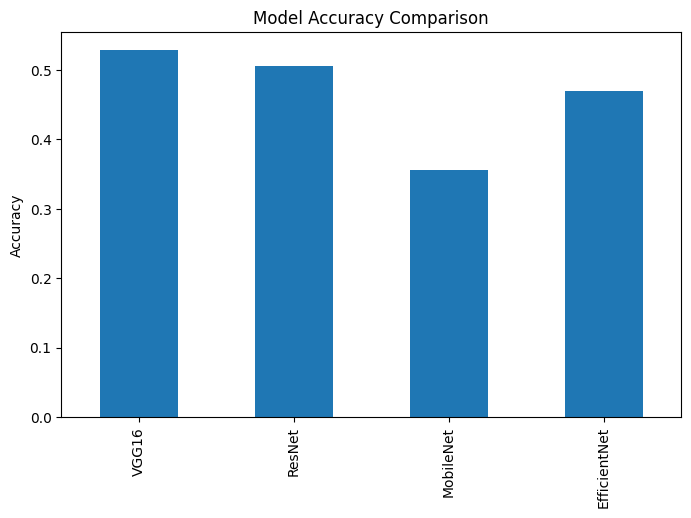

In [65]:
results_df["Accuracy"].plot(kind="bar", figsize=(8,5))

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

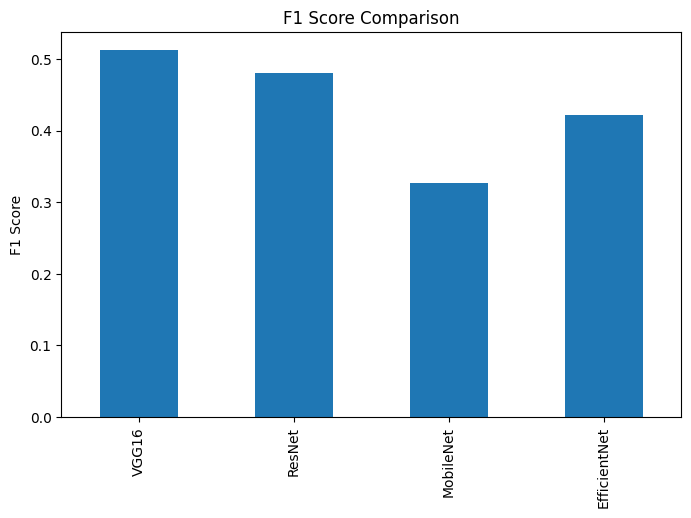

In [66]:
results_df["F1"].plot(kind="bar", figsize=(8,5))

plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")

plt.show()

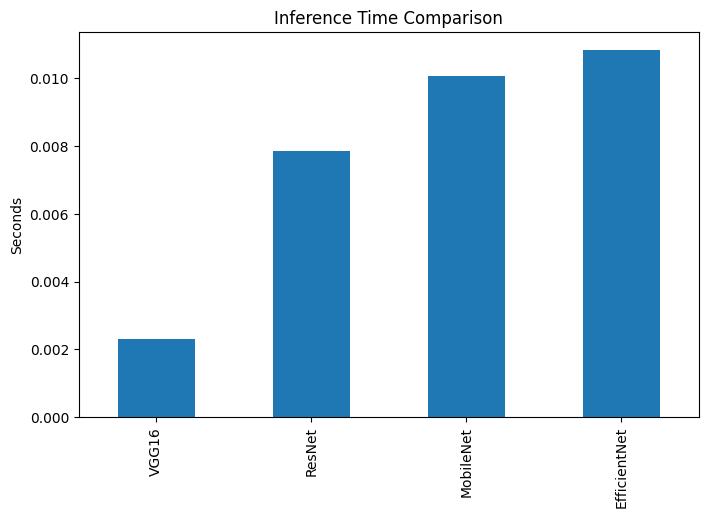

In [67]:
results_df["Inference Time"].plot(kind="bar", figsize=(8,5))

plt.title("Inference Time Comparison")
plt.ylabel("Seconds")

plt.show()

In [68]:
from PIL import Image
from torchvision import transforms
import torch

# evaluation mode
model3.eval()

# transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# load image
img_path = "/content/Smart_Vision/classification/test/bed/bed_test_0006.jpg"
image = Image.open(img_path).convert("RGB")

# preprocess
image = transform(image)

# add batch dimension
image = image.unsqueeze(0).to(device)

# prediction
with torch.no_grad():
    outputs = model3(image)

predicted = torch.argmax(outputs, dim=1)

print("Prediction:", class_names[predicted.item()])

Prediction: bed


# Detection Model

In [69]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.9 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

In [71]:
model_det = YOLO("yolov8n.pt")

In [72]:
results = model_det.train(

    data="/content/Smart_Vision/detection/data.yaml",

    epochs=50,

    imgsz=640,

    batch=16,

    device=0,

    optimizer="Adam",

    lr0=0.001,

    pretrained=True,

    patience=5,

    workers=2,

    project="/content/drive/MyDrive/Smart_Vision/yolo_runs",

    name="yolov8n_detection"
)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Smart_Vision/detection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_ma

In [73]:
best_model_det = YOLO(
    "/content/drive/MyDrive/Smart_Vision/yolo_runs/yolov8n_detection/weights/best.pt"
)

In [74]:
metrics = best_model_det.val()

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,010,718 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 571.2±972.0 MB/s, size: 142.7 KB)
val: Scanning /content/Smart_Vision/detection/labels.cache... 2210 images, 0 backgrounds, 1687 corrupt: 100% ━━━━━━━━━━━━ 2210/2210 842.7Mit/s 0.0s
train: /content/Smart_Vision/detection/images/image_000001.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0362      1.3258      1.1337      1.0276      1.0265      1.3846]
train: /content/Smart_Vision/detection/images/image_000002.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0362      1.3258      1.1337      1.0276      1.0265      1.3846]
train: /content/Smart_Vision/detection/images/image_000003.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0362      1.3258      1.1337      1

In [75]:
model_det_2 = YOLO("yolov8s.pt")

In [76]:
results_model_det2 = model_det_2.train(

    data="/content/Smart_Vision/detection/data.yaml",

    epochs=50,

    imgsz=960,

    batch=16,

    device=0,

    optimizer="SGD",

    lr0=0.001,

    pretrained=True,

    patience=5,

    workers=2,

    project="/content/drive/MyDrive/Smart_Vision/yolo_runs",

    name="yolov8s_detection"
)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Smart_Vision/detection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mas

In [77]:
best_model2 = YOLO(
    "/content/drive/MyDrive/Smart_Vision/yolo_runs/yolov8s_detection/weights/best.pt"
)

In [78]:
metrics2 = best_model2.val()

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,135,646 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 520.0±997.2 MB/s, size: 168.7 KB)
val: Scanning /content/Smart_Vision/detection/labels.cache... 2210 images, 0 backgrounds, 1687 corrupt: 100% ━━━━━━━━━━━━ 2210/2210 842.7Mit/s 0.0s
train: /content/Smart_Vision/detection/images/image_000001.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0362      1.3258      1.1337      1.0276      1.0265      1.3846]
train: /content/Smart_Vision/detection/images/image_000002.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0362      1.3258      1.1337      1.0276      1.0265      1.3846]
train: /content/Smart_Vision/detection/images/image_000003.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0362      1.3258      1.1337     

In [6]:
model_det_3 = YOLO("yolov8m.pt")

In [7]:
results_model_det3 = model_det_3.train(

    data="/content/Smart_Vision/detection/data.yaml",

    epochs=50,

    imgsz=960,

    batch=16,

    device=0,

    optimizer="SGD",

    lr0=0.001,

    pretrained=True,

    patience=5,

    workers=2,

    project="/content/drive/MyDrive/Smart_Vision/yolo_runs",

    name="yolov8m_detection"
)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Smart_Vision/detection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_detection-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_m

In [9]:
best_model3 = YOLO(
    "/content/drive/MyDrive/Smart_Vision/yolo_runs/yolov8m_detection/weights/best.pt"
)

In [10]:
metrics3 = best_model3.val()

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,854,814 parameters, 0 gradients, 78.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 441.8±843.6 MB/s, size: 142.7 KB)
val: Scanning /content/Smart_Vision/detection/labels.cache... 2210 images, 0 backgrounds, 1687 corrupt: 100% ━━━━━━━━━━━━ 2210/2210 662.1Mit/s 0.0s
train: /content/Smart_Vision/detection/images/image_000001.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0362      1.3258      1.1337      1.0276      1.0265      1.3846]
train: /content/Smart_Vision/detection/images/image_000002.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0362      1.3258      1.1337      1.0276      1.0265      1.3846]
train: /content/Smart_Vision/detection/images/image_000003.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0362      1.3258      1.1337     

In [14]:
# print(metrics)
# print(metrics2)
# print(metrics3)